In [10]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 90)

In [11]:
# Partie 1 - Exploration du corpus

## 1) Chargement des données
df = pd.read_csv("../data/smart_reviews_raw.csv")
df.head(10)

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.,positif,5,fr
5,AV0006,2026-07-26,web,Ordinateur NovaBook,Très satisfait de mon achat 👍 😊,positif,5,fr
6,AV0007,2026-05-22,email,Ordinateur NovaBook,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPIDEMENT.,positif,4,fr
7,AV0008,2026-06-30,web,SmartPhone X,Très satisfait de mon achat 👍,positif,5,fr
8,AV0009,2026-08-10,web,Écouteurs AirSound,Le produit correspond globalement à la description.,neutre,3,fr
9,AV0010,2026-04-01,mobile,Ordinateur NovaBook,@client Livraison rapide et produit conforme à mes attentes.,positif,5,fr


In [12]:
## 2) Combien d'avis contient le dataset ?

print(f"Nombre d'avis : {len(df)}")

Nombre d'avis : 1200


In [13]:
## 3) Combien de colonnes possède-t-il ?

print(f"Nombre de colonnes : {df.shape[1]}")
print(list(df.columns))

Nombre de colonnes : 8
['id_avis', 'date', 'source', 'produit', 'texte', 'sentiment', 'note', 'langue']


In [14]:
# 4) Type de chaque colonne
# Pourquoi : le type d'une colonne décide de ce qu'on peut faire avec
# (une moyenne se calcule sur des nombres, un nettoyage s'applique à du texte).
df.dtypes

# Réponse : toutes les colonnes sont de type texte (object) sauf `note`, qui est un entier (int64).
# La colonne `date` est lue comme du texte : on pourra la convertir avec pd.to_datetime si besoin.

id_avis      object
date         object
source       object
produit      object
texte        object
sentiment    object
note          int64
langue       object
dtype: object

In [15]:
# 5) Existe-t-il des valeurs manquantes ?
# Pourquoi : un texte manquant (NaN) ne peut ni être nettoyé ni transformé en nombres,
# il faudra donc le supprimer avant de continuer.

# Nombre de valeurs manquantes (NaN) dans chaque colonne
print(df.isna().sum())
print()

# Un texte peut aussi être "vide" sans être NaN, s'il ne contient que des espaces
print("Textes composés uniquement d'espaces :", (df["texte"].fillna("x").str.strip() == "").sum())

# Réponse : oui, uniquement dans la colonne `texte` : 5 valeurs manquantes (NaN),
# auxquelles s'ajoute 1 texte composé uniquement d'espaces, soit 6 textes vides au total.
# Les autres colonnes sont complètes.

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

Textes composés uniquement d'espaces : 1


In [16]:
# 6) Identifier quelques types de texte
# Pourquoi : repérer les problèmes de qualité du corpus pour savoir quoi traiter au nettoyage.

# On remplace les NaN par "" pour que les fonctions de texte ne plantent pas
texte = df["texte"].fillna("")

# Motifs de recherche (expressions régulières), définis une fois pour être réutilisés plus tard
RE_URL     = r"https?://\S+|www\.\S+"                 # http://... ou www....
RE_MENTION = r"@\w+"                                  # @pseudo
RE_HASHTAG = r"#\w+"                                  # #mot
RE_EMOJI   = r"[\U0001F300-\U0001FAFF\u2600-\u27BF]"  # plages Unicode des emojis
RE_PONCT   = r"[!?.,;:]{2,}"                          # ponctuation répétée (!!, ?!, ...)
RE_REPET   = r"([a-zA-ZÀ-ÿ])\1{2,}"                   # même lettre 3 fois d'affilée (superrrr)

# Fonction : vrai si le texte est écrit uniquement en majuscules
def est_majuscules(s):
    lettres = [c for c in s if c.isalpha()]
    return len(lettres) > 3 and all(c.isupper() for c in lettres)

# Un masque par type : une série de vrai/faux, une valeur par avis
masques = {
    "texte vide"           : texte.str.strip() == "",
    "contient une URL"     : texte.str.contains(RE_URL, regex=True),
    "contient une mention" : texte.str.contains(RE_MENTION, regex=True),
    "contient un hashtag"  : texte.str.contains(RE_HASHTAG, regex=True),
    "contient des emojis"  : texte.str.contains(RE_EMOJI, regex=True),
    "ponctuation répétée"  : texte.str.contains(RE_PONCT, regex=True),
    "texte en MAJUSCULES"  : texte.apply(est_majuscules),
    "lettres répétées"     : texte.str.contains(RE_REPET, regex=True),
}

# Texte "normal" = aucun des problèmes ci-dessus
normal = ~pd.concat(masques.values(), axis=1).any(axis=1)
print("Exemple de texte normal :", texte[normal].iloc[0])

# Pour chaque type : nombre d'avis concernés et 3 exemples
for nom, m in masques.items():
    print(f"\n--- {nom} : {m.sum()} avis")
    for ex in texte[m].head(3):
        print("   ", repr(ex))

# Réponse : le corpus contient bien tous ces cas (textes vides, URLs, mentions, hashtags,
# emojis, ponctuation répétée, majuscules, lettres répétées) : il faudra les traiter en Partie 2.

Exemple de texte normal : Très  bonne  expérience,  simple  et  efficace.

--- texte vide : 6 avis
    ''
    ''
    ''

--- contient une URL : 143 avis
    'Produit parfait, rien à signaler. https://example.com/commande/17'
    'Très bonne expérience, simple et efficace. https://example.com/commande/31'
    'Je viens de recevoir le produit, à voir dans le temps. https://example.com/commande/32'

--- contient une mention : 128 avis
    '@client Livraison rapide et produit conforme à mes attentes.'
    '@client Service client réactif et commande reçue rapidement.'
    '@client La qualité est correcte sans être exceptionnelle.'

--- contient un hashtag : 127 avis
    'Très satisfait de mon achat 👍 #avis'
    "La batterie tient vraiment bien et l'écran est superbe. #avis"
    'Produit correct pour son prix. #avis'

--- contient des emojis : 192 avis
    'Très satisfait de mon achat 👍 #avis'
    'Très satisfait de mon achat 👍 😊'
    'Très  satisfait  de  mon  achat  👍'

--- ponctuation rép

C:\Users\dell\AppData\Local\Temp\ipykernel_18304\21312265.py:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "lettres répétées"     : texte.str.contains(RE_REPET, regex=True),


In [17]:
# 7) Mesurer la longueur des textes
# Pourquoi : la longueur (en caractères) permet de repérer les textes trop courts ou trop longs,
# qui peuvent être des anomalies ou apporter peu d'information au modèle.

# Nouvelle colonne "longueur" : nombre de caractères de chaque texte
# (les textes manquants sont comptés pour 0)
df["longueur"] = df["texte"].fillna("").str.len()

# Statistiques descriptives de la longueur
stats = df["longueur"].describe()
print(f"Minimum  : {int(stats['min'])}")
print(f"Maximum  : {int(stats['max'])}")
print(f"Moyenne  : {stats['mean']:.2f}")
print(f"Médiane  : {df['longueur'].median():.0f}")
print(f"Q1 (25%) : {stats['25%']:.0f}")
print(f"Q3 (75%) : {stats['75%']:.0f}")

# Réponse : les avis font en moyenne environ 49 caractères, avec une médiane de 48.
# La moitié des avis se situe entre 37 et 56 caractères (Q1 à Q3).
# Le minimum est 0 (textes vides) et le maximum 636, ce qui est très éloigné du reste.

Minimum  : 0
Maximum  : 636
Moyenne  : 48.96
Médiane  : 48
Q1 (25%) : 37
Q3 (75%) : 56


In [18]:
# 7) Mesurer la longueur des textes
# Pourquoi : la longueur (en caractères) permet de repérer les textes trop courts ou trop longs,
# qui peuvent être des anomalies ou apporter peu d'information au modèle.

# Nouvelle colonne "longueur" : nombre de caractères de chaque texte
# (les textes manquants sont comptés pour 0)
df["longueur"] = df["texte"].fillna("").str.len()

# Statistiques descriptives de la longueur
stats = df["longueur"].describe()
print(f"Minimum  : {int(stats['min'])}")
print(f"Maximum  : {int(stats['max'])}")
print(f"Moyenne  : {stats['mean']:.2f}")
print(f"Médiane  : {df['longueur'].median():.0f}")
print(f"Q1 (25%) : {stats['25%']:.0f}")
print(f"Q3 (75%) : {stats['75%']:.0f}")

# Réponse : les avis font en moyenne environ 49 caractères, avec une médiane de 48.
# La moitié des avis se situe entre 37 et 56 caractères (Q1 à Q3).
# Le minimum est 0 (textes vides) et le maximum 636, ce qui est très éloigné du reste.

Minimum  : 0
Maximum  : 636
Moyenne  : 48.96
Médiane  : 48
Q1 (25%) : 37
Q3 (75%) : 56


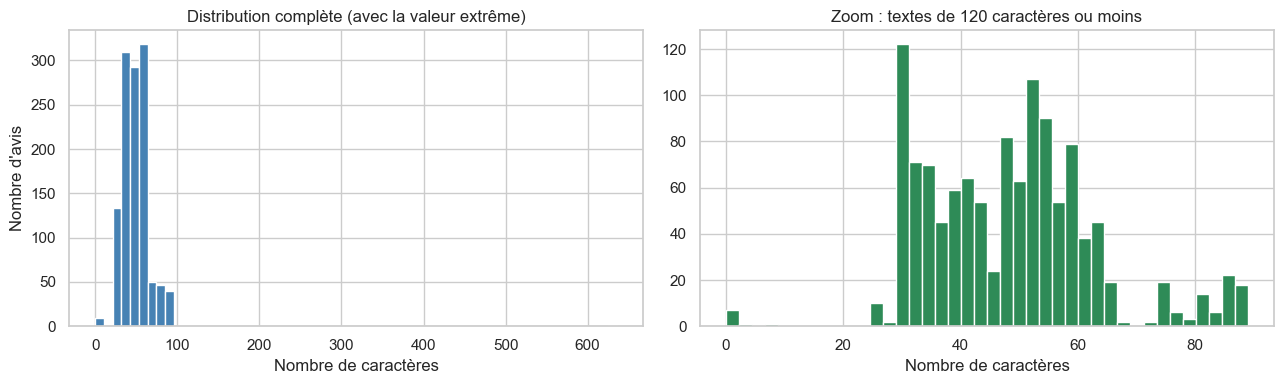

In [19]:
# 8) Visualiser la distribution de la longueur des avis
# Pourquoi : un graphique montre d'un coup d'oeil où se concentrent les longueurs
# et si des valeurs isolées (très courtes ou très longues) existent.

# Deux graphiques côte à côte : 1 ligne, 2 colonnes
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Graphique 1 : distribution complète, avec la valeur extrême
axes[0].hist(df["longueur"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution complète (avec la valeur extrême)")
axes[0].set_xlabel("Nombre de caractères")
axes[0].set_ylabel("Nombre d'avis")

# Graphique 2 : zoom sur les textes de 120 caractères ou moins
axes[1].hist(df.loc[df["longueur"] <= 120, "longueur"], bins=40, color="seagreen", edgecolor="white")
axes[1].set_title("Zoom : textes de 120 caractères ou moins")
axes[1].set_xlabel("Nombre de caractères")
axes[0].set_ylabel("Nombre d'avis")
plt.tight_layout()
plt.show()

# Observation : la grande majorité des avis se concentre entre environ 30 et 60 caractères.
# Sur le graphique complet, une barre isolée très à droite (autour de 636) écrase tout le reste,
# c'est pourquoi le second graphique zoome sur les textes courts pour bien voir la forme de la distribution.

In [20]:
# 8a) Existe-t-il des textes anormalement longs ?
# Pourquoi : on regarde les textes les plus longs et on les compare au reste du corpus.

# Les 3 textes les plus longs
print(df.nlargest(3, "longueur")[["id_avis", "longueur", "texte"]].to_string())

# Seuil en dessous duquel se trouvent 99 % des avis
print("\nLongueur maximale pour 99 % des avis :", df["longueur"].quantile(0.99))

# Réponse : oui, un seul texte est anormalement long : l'avis AV0666 (636 caractères),
# alors que 99 % des avis font 87 caractères ou moins. On y voit la même phrase répétée
# plusieurs fois : c'est probablement une erreur de collecte, à traiter comme une anomalie.

     id_avis  longueur                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         texte
665   AV0666       636  Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longu

In [21]:
# 8b) Existe-t-il beaucoup de textes très courts ?
# Pourquoi : un texte de quelques caractères contient trop peu d'information
# pour que le modèle puisse en déduire un sentiment.

# On considère "très court" un texte de 15 caractères ou moins
courts = df[df["longueur"] <= 15]

print("Nombre de textes très courts (<= 15 caractères) :", len(courts))
print(courts[["id_avis", "texte", "longueur", "sentiment"]].to_string())

# Réponse : non, il y en a très peu : 9 avis sur 1200, dont 6 sont vides.
# Les 3 autres sont de vrais textes brefs. La distribution est concentrée
# entre 37 et 56 caractères (Q1 à Q3), donc les textes très courts sont l'exception.

Nombre de textes très courts (<= 15 caractères) : 9
    id_avis    texte  longueur sentiment
46   AV0047      NaN         0   positif
108  AV0109      NaN         0   positif
224  AV0225       OK         2   positif
310  AV0311      NaN         0   positif
554  AV0555  Pas bon         7    neutre
640  AV0641      NaN         0   positif
781  AV0782      NaN         0    neutre
889  AV0890       OK         2   positif
951  AV0952                  3   positif


In [22]:
# 9) Détecter les textes vides
# Pourquoi : un texte vide ne contient aucune information, il ne peut pas servir
# à classer un sentiment. Il faudra donc les supprimer en Partie 2.

# Un texte est "vide" s'il est manquant (NaN) OU s'il ne contient que des espaces
vides = df[df["texte"].fillna("").str.strip() == ""]

print(f"Nombre de textes vides : {len(vides)}")
print(vides[["id_avis", "texte", "sentiment", "note"]].to_string())

# Réponse : il y a 6 textes vides : 5 valeurs manquantes (NaN) et 1 texte composé uniquement d'espaces (AV0952).
# Ces avis ont pourtant un sentiment et une note, mais sans texte on ne peut rien en apprendre : on les supprimera.

Nombre de textes vides : 6
    id_avis texte sentiment  note
46   AV0047   NaN   positif     4
108  AV0109   NaN   positif     5
310  AV0311   NaN   positif     5
640  AV0641   NaN   positif     5
781  AV0782   NaN    neutre     4
951  AV0952         positif     4


In [24]:
# 10) Détecter les doublons sur le texte
# Pourquoi : des textes identiques n'apportent pas d'information nouvelle et faussent l'apprentissage
# (le modèle "connaît par coeur" ces textes). Pire, si un même texte se retrouve à la fois dans
# le train et dans le test, le score sera artificiellement gonflé.

# On ignore les textes manquants et les textes vides (déjà traités à la tâche 9)
txt = df["texte"].dropna()
txt = txt[txt.str.strip() != ""]

# 1) Doublons exacts : un doublon est un texte déjà vu plus haut dans le tableau
print("Textes non vides                :", len(txt))
print("Doublons exacts                 :", txt.duplicated().sum())
print("Textes uniques (exacts)         :", txt.nunique())

# 2) Doublons après normalisation légère : on met en minuscules et on réduit les espaces multiples
norm = txt.str.lower().str.split().str.join(" ")
print("Doublons après casse + espaces  :", norm.duplicated().sum())
print("Textes uniques après ces normalisations :", norm.nunique())

# 3) Les textes les plus répétés
print("\nTextes les plus répétés :")
print(txt.value_counts().head(3).to_string())

# Réponse : le corpus est très redondant : sur 1194 textes non vides, 877 sont des doublons exacts
# (seulement 317 textes uniques). Après passage en minuscules et réduction des espaces, il n'en reste
# que 268 uniques. Ces doublons seront supprimés en Partie 2, après nettoyage.

Textes non vides                : 1194
Doublons exacts                 : 877
Textes uniques (exacts)         : 317
Doublons après casse + espaces  : 926
Textes uniques après ces normalisations : 268

Textes les plus répétés :
texte
Excellent rapport qualité-prix.                         29
Livraison rapide et produit conforme à mes attentes.    19
Très satisfait de mon achat 👍                           19


           effectif  pourcentage
sentiment                       
positif         776         64.7
neutre          246         20.5
negatif         178         14.8


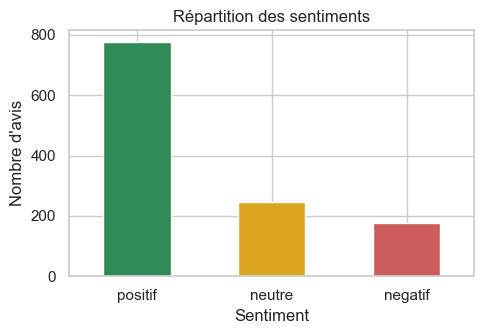

In [25]:
# 11) Les classes sont-elles équilibrées ?
# Pourquoi : si une classe domine, un modèle peut sembler bon
# juste en répondant presque toujours cette classe.

# Nombre d'avis et pourcentage pour chaque sentiment
comptes = df["sentiment"].value_counts()
proportions = df["sentiment"].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({"effectif": comptes, "pourcentage": proportions}))

# Graphique en barres
plt.figure(figsize=(5, 3.5))
comptes.plot(kind="bar", color=["seagreen", "goldenrod", "indianred"], edgecolor="white")
plt.title("Répartition des sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Réponse : non, les classes sont déséquilibrées.
# positif : 776 avis (64,7 %), neutre : 246 (20,5 %), négatif : 178 (14,8 %).
# La classe positive est beaucoup plus grande que les autres.

In [26]:
# 12) Quelle est la classe majoritaire ?
# Pourquoi : la classe majoritaire donne le score "de base" à battre.

# On compte les avis par sentiment
comptes = df["sentiment"].value_counts()

# La classe la plus fréquente
majoritaire = comptes.idxmax()

print("Classe majoritaire :", majoritaire)
print("Nombre d'avis      :", comptes.max())
print(f"Pourcentage        : {comptes.max() / len(df) * 100:.1f} %")

# Réponse : la classe majoritaire est "positif" (776 avis, soit 64,7 %).
# Un modèle qui répondrait toujours "positif" aurait environ 65 % de bonnes réponses sans rien apprendre.

Classe majoritaire : positif
Nombre d'avis      : 776
Pourcentage        : 64.7 %


In [ ]:
# 13) Quelles métriques de classification envisager ?
# Pourquoi : il faut des métriques justes quand une classe
# est beaucoup plus grande que les autres.

# Score d'un "faux modèle" qui répond toujours la classe majoritaire
score_de_base = df["sentiment"].value_counts(normalize=True).max()
print(f"Accuracy d'un modèle qui répond toujours 'positif' : {score_de_base:.1%}")

l'accuracy seule est trompeuse, car un modèle qui ne fait rien
d'intelligent a déjà environ 65 %. On utilisera donc :
 précision, rappel et F1-score pour CHAQUE classe
 F1-score macro : moyenne des F1 des classes, chaque classe compte autant
 matrice de confusion : montre quelles classes sont confondues
 (par exemple neutre confondu avec positif)
 balanced accuracy : moyenne des rappels de chaque classe
 L'accuracy peut rester en complément, mais jamais seule.

In [27]:
# 14) Détecter les caractères particuliers
# Pourquoi : chaque type de caractère demande un traitement précis au nettoyage.
# On compte donc combien d'avis sont concernés par chacun.
# (On réutilise `texte`, les motifs RE_... et la fonction est_majuscules de la tâche 6.)

# Un test par type : vrai si l'avis contient ce type de caractère
caracteres = {
    "emojis"              : texte.str.contains(RE_EMOJI, regex=True),
    "URLs"                : texte.str.contains(RE_URL, regex=True),
    "hashtags"            : texte.str.contains(RE_HASHTAG, regex=True),
    "mentions"            : texte.str.contains(RE_MENTION, regex=True),
    "chiffres"            : texte.str.contains(r"\d", regex=True),
    "ponctuation répétée" : texte.str.contains(RE_PONCT, regex=True),
    "lettres répétées"    : texte.str.contains(RE_REPET, regex=True),
    "caractères spéciaux" : texte.str.contains(r"[^\w\s.,;:!?'’\-]", regex=True),
    "MAJUSCULES"          : texte.apply(est_majuscules),
    "espaces multiples"   : texte.str.contains(r"\s{2,}", regex=True),
}

# Nombre d'avis concernés par chaque type, du plus fréquent au moins fréquent
resume = pd.Series({nom: int(masque.sum()) for nom, masque in caracteres.items()})
print(resume.sort_values(ascending=False).to_string())

# Détail : exemples de chiffres et liste des emojis
print("\nExemples avec chiffres :", texte[caracteres["chiffres"]].head(3).tolist())
print("Emojis trouvés :", texte.str.findall(RE_EMOJI).explode().dropna().value_counts().to_dict())



caractères spéciaux    569
emojis                 192
MAJUSCULES             144
URLs                   143
chiffres               142
ponctuation répétée    141
mentions               128
hashtags               127
espaces multiples      125
lettres répétées        16

Exemples avec chiffres : ['Produit parfait, rien à signaler. https://example.com/commande/17', 'Très bonne expérience, simple et efficace. https://example.com/commande/31', 'Je viens de recevoir le produit, à voir dans le temps. https://example.com/commande/32']
Emojis trouvés : {'😊': 124, '👍': 76, '😍': 3, '😡': 2}


C:\Users\dell\AppData\Local\Temp\ipykernel_18304\2235398806.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "lettres répétées"    : texte.str.contains(RE_REPET, regex=True),


  tous ces caractères sont présents dans plusieurs dizaines d'avis.
 Les chiffres viennent surtout des URLs (ex : .../commande/17) : ils disparaîtront avec elles.
 Les caractères spéciaux sont surtout les emojis, les # et les @.
 Il y a 4 emojis différents. Ils portent du sentiment (😊 👍 😍 😡), donc à garder ou à traduire en mots.

source
réseaux_sociaux    251
email              247
sav                239
web                232
mobile             230
WEB                  1
Name: count, dtype: int64


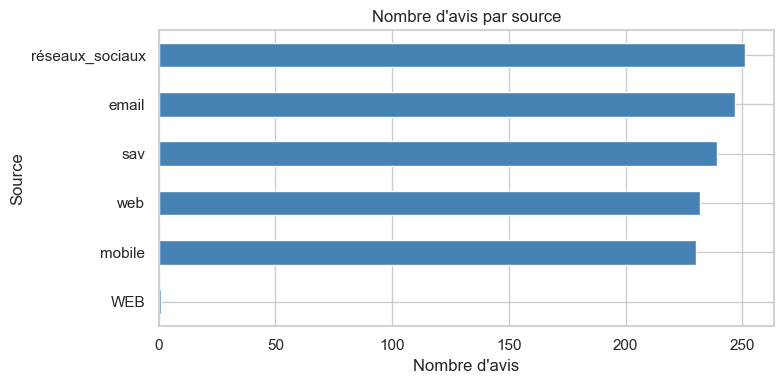

In [28]:
# 15) Visualiser et commenter le nombre d'avis par source
# Pourquoi : voir si toutes les sources sont bien représentées,
# ou si une source domine et risque de biaiser le modèle.

# Nombre d'avis par source
comptes_source = df["source"].value_counts()
print(comptes_source)

# Graphique en barres horizontales
plt.figure(figsize=(8, 4))
comptes_source.sort_values().plot(kind="barh", color="steelblue", edgecolor="white")
plt.title("Nombre d'avis par source")
plt.xlabel("Nombre d'avis")
plt.ylabel("Source")
plt.tight_layout()
plt.show()


Commentaire : les avis sont répartis de façon presque égale entre les 5 sources,
 entre 230 et 251 avis chacune (réseaux sociaux : 251, email : 247, sav : 239, web : 232, mobile : 230).
Aucune source ne domine, donc pas de biais lié à la source.
 Problème : une ligne a la valeur "WEB" en majuscules (AV0951). C'est la même source que "web".
 C'est une erreur de saisie, à corriger au nettoyage en mettant la colonne en minuscules.

produit
Écouteurs AirSound     218
Ordinateur NovaBook    217
SmartPhone X           201
SmartWatch Pro         193
Tablette TabPlus       187
SmartPhone Y           184
Name: count, dtype: int64


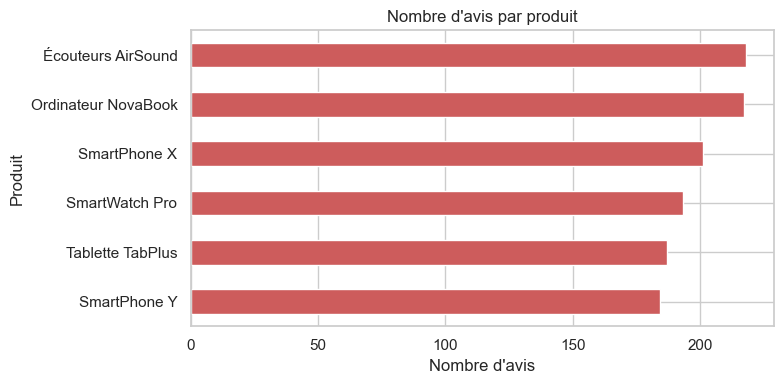

In [29]:
# 16) Visualiser et commenter le nombre d'avis par produit
# Pourquoi : voir si tous les produits sont bien représentés,
# ou si un produit domine et risque de biaiser le modèle.

# Nombre d'avis par produit
comptes_produit = df["produit"].value_counts()
print(comptes_produit)

# Graphique en barres horizontales
plt.figure(figsize=(8, 4))
comptes_produit.sort_values().plot(kind="barh", color="indianred", edgecolor="white")
plt.title("Nombre d'avis par produit")
plt.xlabel("Nombre d'avis")
plt.ylabel("Produit")
plt.tight_layout()
plt.show()


 Commentaire : il y a 6 produits, avec entre 184 et 218 avis chacun.
 Écouteurs AirSound (218) et Ordinateur NovaBook (217) sont un peu plus représentés,
 SmartPhone Y (184) un peu moins, mais l'écart reste faible.
 Aucun produit ne domine : le corpus n'est pas biaisé vers un produit.
 Le vrai déséquilibre du dataset vient donc de la colonne "sentiment", pas du produit.

Partie 2 – Nettoyage 

In [30]:
# 1) Supprimer les lignes dont le texte est manquant
# Pourquoi : un avis sans texte ne peut pas être classé.
# On garde `df` intact (données brutes) et on travaille sur une copie : `df_clean`.

print("Avant :", len(df))

# On garde seulement les lignes où `texte` n'est pas manquant
df_clean = df.dropna(subset=["texte"]).copy()

# On refait la numérotation des lignes de 0 à n-1
df_clean = df_clean.reset_index(drop=True)

print("Après :", len(df_clean))
print("Lignes supprimées :", len(df) - len(df_clean))
print("Textes manquants restants :", df_clean["texte"].isna().sum())

# Réponse : 5 lignes supprimées, il reste 1195 avis.
# Le texte fait uniquement d'espaces (AV0952) n'est pas un NaN : il sera retiré
# plus tard, quand on nettoiera les espaces.

Avant : 1200
Après : 1195
Lignes supprimées : 5
Textes manquants restants : 0


In [31]:
# 2) Supprimer les doublons
# Pourquoi : des textes identiques n'apprennent rien de nouveau au modèle.
# Pire : si le même texte est dans le train ET dans le test, le score du test est faussé.

print("Avant :", len(df_clean))
print("Doublons exacts sur le texte :", df_clean.duplicated(subset=["texte"]).sum())

# On garde la première apparition de chaque texte, on supprime les autres
df_clean = df_clean.drop_duplicates(subset=["texte"], keep="first").reset_index(drop=True)

print("Après :", len(df_clean))
print("Doublons restants :", df_clean.duplicated(subset=["texte"]).sum())

# Effet sur les classes
print("\nRépartition des sentiments après suppression :")
print(df_clean["sentiment"].value_counts())


Avant : 1195
Doublons exacts sur le texte : 877
Après : 318
Doublons restants : 0

Répartition des sentiments après suppression :
sentiment
positif    160
neutre      79
negatif     79
Name: count, dtype: int64


In [32]:
# 3) Supprimer les URLs
# Pourquoi : une URL ne dit rien sur le sentiment et elle est différente à chaque avis
# On crée la colonne `texte_clean` : au début, c'est une copie du texte d'origine
df_clean["texte_clean"] = df_clean["texte"]

# Combien d'avis ont une URL avant nettoyage ?
avant = df_clean["texte_clean"].str.contains(RE_URL, regex=True).sum()

# On remplace chaque URL par rien
df_clean["texte_clean"] = df_clean["texte_clean"].str.replace(RE_URL, "", regex=True)

# Combien après ?
apres = df_clean["texte_clean"].str.contains(RE_URL, regex=True).sum()
print("Avis avec URL avant :", avant)
print("Avis avec URL après :", apres)

# Comparaison sur 3 exemples
exemples = df_clean[df_clean["texte"].str.contains(RE_URL, regex=True)].head(3)
for i, ligne in exemples.iterrows():
    print("\nAvant :", repr(ligne["texte"]))
    print("Après :", repr(ligne["texte_clean"]))


Avis avec URL avant : 143
Avis avec URL après : 0

Avant : 'Produit parfait, rien à signaler. https://example.com/commande/17'
Après : 'Produit parfait, rien à signaler. '

Avant : 'Très bonne expérience, simple et efficace. https://example.com/commande/31'
Après : 'Très bonne expérience, simple et efficace. '

Avant : 'Je viens de recevoir le produit, à voir dans le temps. https://example.com/commande/32'
Après : 'Je viens de recevoir le produit, à voir dans le temps. '


In [33]:
# 4) Traiter les mentions et les hashtags
# Stratégie pour un modèle de sentiment :
# - mentions (@client) : on les supprime, un pseudo ne porte pas de sentiment
# - hashtags (#avis) : on garde le mot et on enlève le "#", car le mot peut exprimer une opinion

# Ce qu'on trouve dans le corpus
print("Mentions :", df_clean["texte_clean"].str.findall(RE_MENTION).explode().dropna().value_counts().to_dict())
print("Hashtags :", df_clean["texte_clean"].str.findall(RE_HASHTAG).explode().dropna().value_counts().to_dict())

# On supprime les mentions
df_clean["texte_clean"] = df_clean["texte_clean"].str.replace(RE_MENTION, "", regex=True)

# On garde le mot des hashtags : on enlève seulement le "#"
df_clean["texte_clean"] = df_clean["texte_clean"].str.replace("#", "", regex=False)

# Vérification
print("\nMentions restantes :", df_clean["texte_clean"].str.contains(RE_MENTION, regex=True).sum())
print("Symboles # restants :", df_clean["texte_clean"].str.contains("#", regex=False).sum())

# Comparaison sur 4 exemples
exemples = df_clean[df_clean["texte"].str.contains(RE_MENTION + "|" + RE_HASHTAG, regex=True)].head(4)
for i, ligne in exemples.iterrows():
    print("\nAvant :", repr(ligne["texte"]))
    print("Après :", repr(ligne["texte_clean"]))

# Réponse : 24 avis avec mention (@client 23 fois, @support 1 fois) et 25 avis avec hashtag
# (#avis 24 fois, #déception 1 fois). Mentions supprimées, hashtags gardés sans le "#".
# Ici #avis est réparti dans les trois classes : il n'aide pas beaucoup, mais il ne gêne pas non plus.
# Des espaces en trop restent au début ou à la fin : ils seront enlevés à la tâche 5.

Mentions : {'@client': 23, '@support': 1}
Hashtags : {'#avis': 24, '#déception': 1}

Mentions restantes : 0
Symboles # restants : 0

Avant : 'Très satisfait de mon achat 👍 #avis'
Après : 'Très satisfait de mon achat 👍 avis'

Avant : '@client Livraison rapide et produit conforme à mes attentes.'
Après : ' Livraison rapide et produit conforme à mes attentes.'

Avant : "La batterie tient vraiment bien et l'écran est superbe. #avis"
Après : "La batterie tient vraiment bien et l'écran est superbe. avis"

Avant : 'Produit correct pour son prix. #avis'
Après : 'Produit correct pour son prix. avis'


In [34]:
# 5) Nettoyer les espaces
# Pourquoi : les espaces en trop (début, fin, doubles) ne changent pas le sens,
# mais rendent deux textes identiques "différents" pour l'ordinateur.

# Texte avant nettoyage
avant = df_clean["texte_clean"]

# On coupe le texte en mots, puis on recolle avec un seul espace
apres = avant.str.split().str.join(" ")

# Nombre d'avis modifiés = nombre de textes différents avant et après
print("Avis modifiés :", (avant != apres).sum())

# On enregistre le résultat
df_clean["texte_clean"] = apres

# Un texte fait uniquement d'espaces est devenu vide : on le supprime
print("Textes devenus vides :", (df_clean["texte_clean"] == "").sum())
print("Avant suppression :", len(df_clean))
df_clean = df_clean[df_clean["texte_clean"] != ""].reset_index(drop=True)
print("Après suppression :", len(df_clean))

# Réponse : 193 avis avaient des espaces en trop, ils sont corrigés.
# Un texte vide (AV0952, fait d'espaces) a été supprimé : il reste 317 avis.

Avis modifiés : 193
Textes devenus vides : 1
Avant suppression : 318
Après suppression : 317
